In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
import Levenshtein

from lib.utils import constants

In [2]:
# Load data
df = pd.read_csv("../data/cytotoxicity/dataset.csv")
df_mut = df[df.id != "wild-type"]

mean_val = df_mut.cytotoxic_activity.mean()
wt_val = df[df.id == "wild-type"].cytotoxic_activity.values

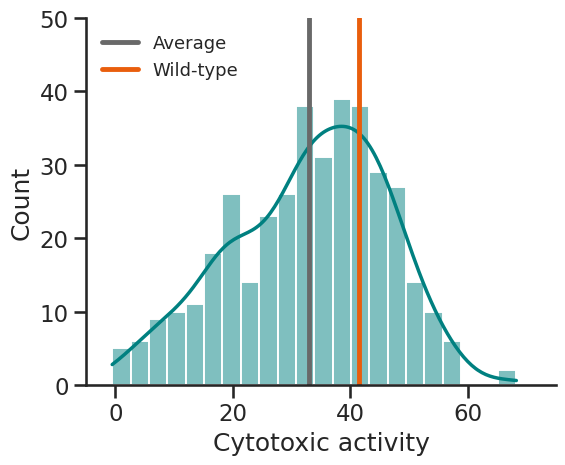

In [3]:
# Cytotoxicity
cols = sns.color_palette("Oranges", 2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.histplot(ax=ax, x=df_mut.cytotoxic_activity, bins=22, kde=True, line_kws={"linewidth": 2.5}, color="teal")
ax.axvline(mean_val, linewidth=3.5, color="dimgray", label="Average")
ax.axvline(wt_val, linewidth=3.5, color=cols[1], label="Wild-type")
ax.set_xlim(-5, 75)
ax.set_ylim(0, 50)
ax.set_xlabel("Cytotoxic activity")
ax.set_ylabel("Count")
ax.legend(loc="upper left", fontsize=13, frameon=False)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/histogram_cytotoxicity.svg")

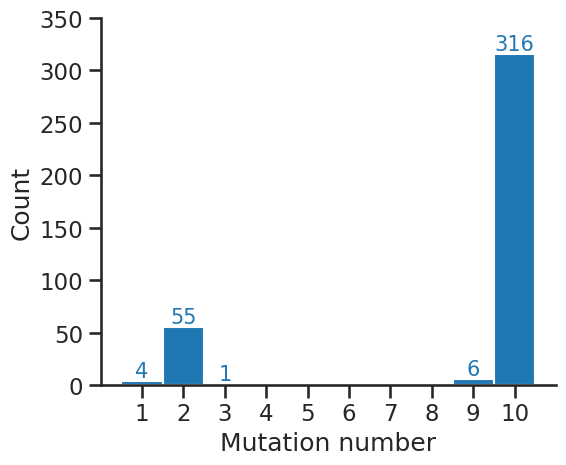

In [4]:
# Mutation number
original_seq = constants.HINGE_28 + constants.TM_28 + constants.COSTIM_28 + constants.ACTIVATION_3Z
mutation_rate = [Levenshtein.distance(seq, original_seq) for seq in df_mut.sequence]
vals, counts = np.unique(mutation_rate, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x=vals, height=counts, width=1, color="tab:blue")
ax.set_xticks(range(1, 11))
for x, y in zip(vals, counts):
    ax.text(x, y, y, ha='center', va='bottom', fontsize=15, color="tab:blue")
ax.set_xlim(0, 11)
ax.set_ylim(0, 350)
ax.set_xlabel("Mutation number")
ax.set_ylabel("Count")
sns.despine()
fig.tight_layout()
fig.savefig("./figures/histogram_mutation.svg")